In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from utils import automated_pipeline

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [2]:
file_raw = r'E:\airta drafts\PREDIKSI KADAR HB\data\raw\erm_hd.xlsx'
df_raw = pd.read_excel(file_raw)

df = automated_pipeline(df_raw)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 639 entries, 0 to 638
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id_pasien        639 non-null    int64         
 1   tgl_pemeriksaan  639 non-null    datetime64[ns]
 2   usia             639 non-null    Int64         
 3   jk               639 non-null    Int64         
 4   eritrosit        639 non-null    float64       
 5   hematokrit       639 non-null    float64       
 6   MCHC             639 non-null    float64       
 7   MCH              639 non-null    float64       
 8   MCV              639 non-null    float64       
 9   hemoglobin       639 non-null    float64       
 10  leukosit         639 non-null    Int64         
 11  trombosit        639 non-null    Int64         
 12  epo              639 non-null    Int64         
dtypes: Int64(5), datetime64[ns](1), float64(6), int64(1)
memory usage: 68.1 KB


In [3]:
df = df.sort_values(by=['id_pasien', 'tgl_pemeriksaan']).reset_index(drop=True)

#LAG FEATURE 
df['hb_lag'] = df.groupby('id_pasien')['hemoglobin'].shift(1)
df['hb_lag2'] = df.groupby('id_pasien')['hemoglobin'].shift(2)

df['hb_delta'] = df['hb_lag'] - df['hb_lag2']

df['inflamasi'] = (df['leukosit'] / 10000) * (df['trombosit'] / 150000)
df['epo_resist'] = df['epo'] / (df['inflamasi'] + 1)

lag_cols = ['hb_lag', 'hb_lag2']
df = df.dropna(subset=lag_cols).reset_index(drop=True)

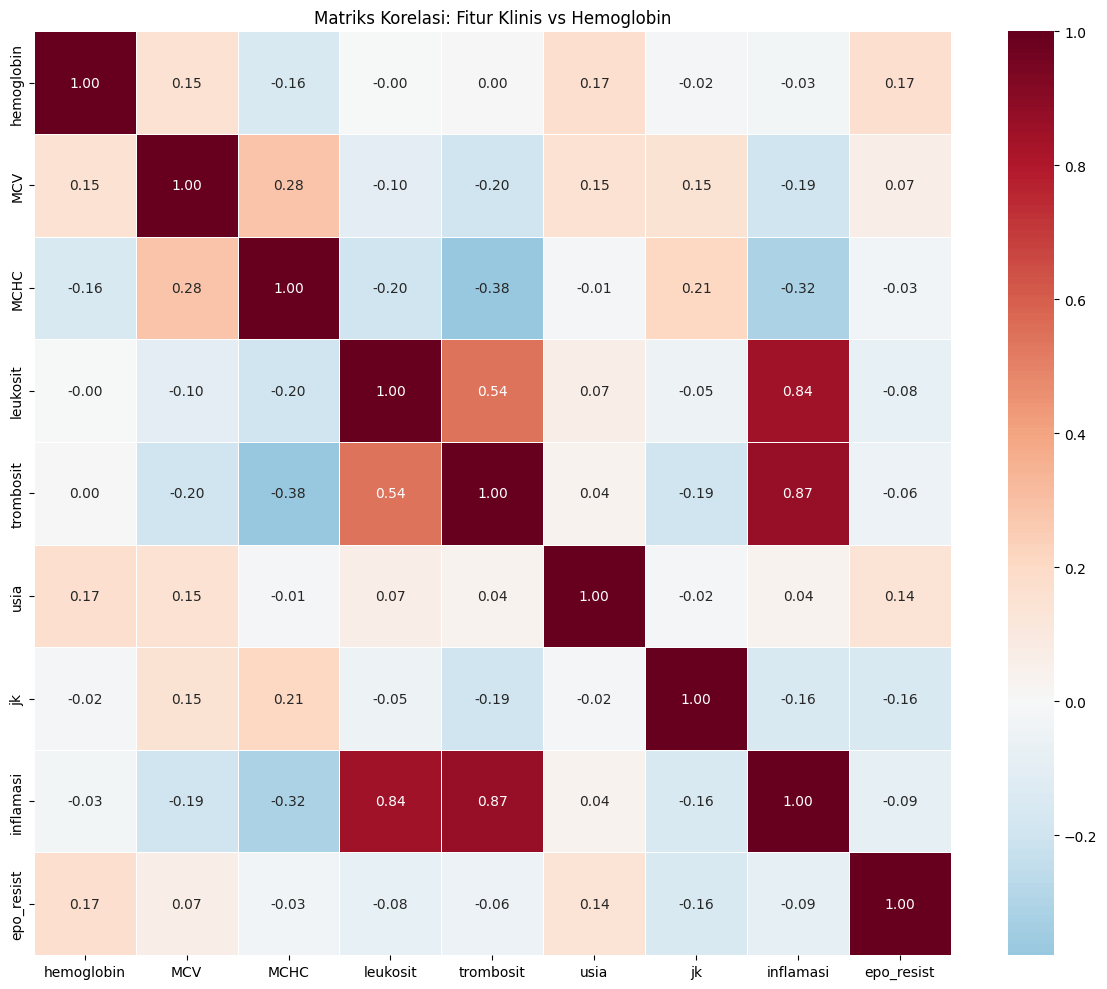

In [4]:
cols_to_corr = [
    'hemoglobin', 'MCV', 'MCHC', 'leukosit', 'trombosit', 'usia', 'jk', 'inflamasi', 'epo_resist'
]

corr_matrix = df[cols_to_corr].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=0.5)

plt.title("Matriks Korelasi: Fitur Klinis vs Hemoglobin")
plt.tight_layout()
plt.show()

In [5]:
#MENENTUKAN FITUR X DAN TARGET Y
X = df.drop(columns=['id_pasien', 'tgl_pemeriksaan', 'hemoglobin', 'hematokrit', 'eritrosit', 'MCH', 'epo', 'inflamasi'])
y = df['hemoglobin']

#SPLIT 80:20 BERDASARKAN KRONOLOGIS
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    shuffle=False
)

print(f"Total baris data: {len(df)}")
print(f"Jumlah Data Latih (80%): {len(X_train)}")
print(f"Jumlah Data Uji (20%): {len(X_test)}")
print("-" * 30)
print("Fitur yang digunakan (X):", X.columns.tolist())

Total baris data: 497
Jumlah Data Latih (80%): 397
Jumlah Data Uji (20%): 100
------------------------------
Fitur yang digunakan (X): ['usia', 'jk', 'MCHC', 'MCV', 'leukosit', 'trombosit', 'hb_lag', 'hb_lag2', 'hb_delta', 'epo_resist']


In [6]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

print(f"Total baris di X_train: {len(X_train)}")
print("-" * 30)

for i, (train_index, val_index) in enumerate(tscv.split(X_train)):
    print(f"Iterasi ke-{i+1}:")
    print(f"  Jumlah Data Latih: {len(train_index)} baris (Indeks {train_index[0]} s/d {train_index[-1]})")
    print(f"  Jumlah Data Validasi: {len(val_index)} baris (Indeks {val_index[0]} s/d {val_index[-1]})")
    print("-" * 30)

Total baris di X_train: 397
------------------------------
Iterasi ke-1:
  Jumlah Data Latih: 67 baris (Indeks 0 s/d 66)
  Jumlah Data Validasi: 66 baris (Indeks 67 s/d 132)
------------------------------
Iterasi ke-2:
  Jumlah Data Latih: 133 baris (Indeks 0 s/d 132)
  Jumlah Data Validasi: 66 baris (Indeks 133 s/d 198)
------------------------------
Iterasi ke-3:
  Jumlah Data Latih: 199 baris (Indeks 0 s/d 198)
  Jumlah Data Validasi: 66 baris (Indeks 199 s/d 264)
------------------------------
Iterasi ke-4:
  Jumlah Data Latih: 265 baris (Indeks 0 s/d 264)
  Jumlah Data Validasi: 66 baris (Indeks 265 s/d 330)
------------------------------
Iterasi ke-5:
  Jumlah Data Latih: 331 baris (Indeks 0 s/d 330)
  Jumlah Data Validasi: 66 baris (Indeks 331 s/d 396)
------------------------------


In [7]:
df_check = df.copy()
df_check['set'] = 'train'
df_check.loc[X_test.index, 'set'] = 'test'

df_check[['id_pasien', 'tgl_pemeriksaan', 'hb_lag', 'hb_lag2', 'hemoglobin', 'set']].iloc[
    len(X_train)-5 : len(X_train)+5
]

,id_pasien,tgl_pemeriksaan,hb_lag,hb_lag2,hemoglobin,set
392,53,2025-10-01,9.3,8.6,8.6,train
393,53,2025-11-01,8.6,9.3,7.0,train
394,53,2025-12-01,7.0,8.6,8.6,train
395,53,2026-01-01,8.6,7.0,7.7,train
396,54,2025-05-01,7.3,8.4,7.6,train
397,54,2025-06-01,7.6,7.3,8.6,test
398,54,2025-07-01,8.6,7.6,9.5,test
399,54,2025-08-01,9.5,8.6,9.0,test
400,54,2025-09-01,9.0,9.5,8.2,test
401,54,2025-10-01,8.2,9.0,8.5,test


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso, ElasticNet, BayesianRidge, LinearRegression
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import time

best_models = {}

# SVR 
print("Menjalankan Grid Search SVR...")
param_grid_svr = {
    'model__C': [1, 10, 100], 
    'model__epsilon': [0.01, 0.1, 0.5], 
    'model__gamma': ['scale', 0.01, 0.1]
}
pipe_svr = Pipeline([('scaler', StandardScaler()), ('model', SVR(kernel='rbf'))])
grid_svr = GridSearchCV(pipe_svr, param_grid_svr, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
start_time = time.time()
grid_svr.fit(X_train, y_train)
best_models['SVR'] = {'best_mae': -grid_svr.best_score_, 'params': grid_svr.best_params_, 'latency': time.time() - start_time}

# RANDOM FOREST
print("Menjalankan Grid Search Random Forest...")
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_leaf': [1, 5]
}
rf = RandomForestRegressor(random_state=42)
grid_rf = GridSearchCV(rf, param_grid_rf, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
start_time = time.time()
grid_rf.fit(X_train, y_train)
latency_rf = time.time() - start_time
best_models['RF'] = {'best_mae': -grid_rf.best_score_, 'params': grid_rf.best_params_, 'latency': latency_rf}

# LIGHTGBM
print("Menjalankan Grid Search LightGBM...")
param_grid_lgbm = {
    'n_estimators': [50, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [7, 15]
}
lgbm = LGBMRegressor(random_state=42, verbose=-1)
grid_lgbm = GridSearchCV(lgbm, param_grid_lgbm, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
start_time = time.time()
grid_lgbm.fit(X_train, y_train)
best_models['LGBM'] = {'best_mae': -grid_lgbm.best_score_, 'params': grid_lgbm.best_params_, 'latency': time.time() - start_time}

# XGBOOST (DENGAN TUNING LEBIH DETAIL)
print("Menjalankan Grid Search XGBoost...")
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}
xgb = XGBRegressor(random_state=42, n_jobs=-1)
grid_xgb = GridSearchCV(xgb, param_grid_xgb, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
start_time = time.time()
grid_xgb.fit(X_train, y_train)
best_models['XGB'] = {'best_mae': -grid_xgb.best_score_, 'params': grid_xgb.best_params_, 'latency': time.time() - start_time}

# PEMBANDING (MLP, LINEAR REGRESSION, LASSO, ELASTIC NET)
# 1. MLP (MULTILAYER PERCEPTRON)
print("Menjalankan Grid Search MLP...")
param_grid_mlp = {
    'model__hidden_layer_sizes': [(50, 50), (100,)], # Mencoba 2 layer vs 1 layer
    'model__activation': ['relu', 'tanh'],
    'model__alpha': [0.0001, 0.01], # Regulasi
    'model__learning_rate_init': [0.001, 0.01]
}
pipe_mlp = Pipeline([('scaler', StandardScaler()), ('model', MLPRegressor(random_state=42, max_iter=1000))])
grid_mlp = GridSearchCV(pipe_mlp, param_grid_mlp, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
start_time = time.time()
grid_mlp.fit(X_train, y_train)
best_models['MLP'] = {'best_mae': -grid_mlp.best_score_, 'params': grid_mlp.best_params_, 'latency': time.time() - start_time}

#2. GRID SEARCH LASSO
print("Menjalankan Grid Search Lasso...")
param_grid_lasso = {
    'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0]
}
pipe_lasso = Pipeline([('scaler', StandardScaler()), ('model', Lasso(random_state=42))])
grid_lasso = GridSearchCV(pipe_lasso, param_grid_lasso, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
start_time = time.time()
grid_lasso.fit(X_train, y_train)
best_models['Lasso'] = {'best_mae': -grid_lasso.best_score_, 'params': grid_lasso.best_params_, 'latency': time.time() - start_time}

# 3. GRID SEARCH ELASTICNET
print("Menjalankan Grid Search ElasticNet...")
param_grid_en = {
    'model__alpha': [0.01, 0.1, 1.0, 10.0],
    'model__l1_ratio': [0.2, 0.5, 0.8]
}
pipe_en = Pipeline([('scaler', StandardScaler()), ('model', ElasticNet(random_state=42))])
grid_en = GridSearchCV(pipe_en, param_grid_en, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
start_time = time.time()
grid_en.fit(X_train, y_train)
best_models['ElasticNet'] = {'best_mae': -grid_en.best_score_, 'params': grid_en.best_params_, 'latency': time.time() - start_time}

# GRID SEARCH BAYESIAN RIDGE
print("Menjalankan Grid Search Bayesian Ridge...")
param_grid_br = {

    'model__max_iter': [300, 600],

    'model__tol': [1e-3, 1e-4]

}
pipe_br = Pipeline([('scaler', StandardScaler()), ('model', BayesianRidge())])
grid_br = GridSearchCV(pipe_br, param_grid_br, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
start_time = time.time()
grid_br.fit(X_train, y_train)
best_models['Bayesian'] = {'best_mae': -grid_br.best_score_, 'params': grid_br.best_params_, 'latency': time.time() - start_time}

# GRID SEARCH LINEAR REGRESSION (BASELINE)
from sklearn.linear_model import LinearRegression
# Kosong karena tidak ada parameter yang di-tuning
param_grid_lr = {}
pipe_lr = Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])
grid_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
start_time = time.time()
grid_lr.fit(X_train, y_train)
latency_lr = time.time() - start_time
best_models['Linear'] = {
    'best_mae': -grid_lr.best_score_,
    'params': 'N/A',
    'latency': latency_lr
}

# --- RINGKASAN AKHIR ---
print("\n=== PERBANDINGAN PERFORMA SEMUA MODEL ===")
for model_name, info in best_models.items():
    print(f"{model_name:10} | MAE: {info['best_mae']:.4f} | Latency: {info['latency']:.2f}s")

Menjalankan Grid Search SVR...
Menjalankan Grid Search Random Forest...
Menjalankan Grid Search LightGBM...
Menjalankan Grid Search XGBoost...
Menjalankan Grid Search MLP...


e:\airta drafts\PREDIKSI KADAR HB\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Menjalankan Grid Search Lasso...
Menjalankan Grid Search ElasticNet...
Menjalankan Grid Search Bayesian Ridge...

=== PERBANDINGAN PERFORMA SEMUA MODEL ===
SVR        | MAE: 0.6432 | Latency: 12.10s
RF         | MAE: 0.6784 | Latency: 10.13s
LGBM       | MAE: 0.6680 | Latency: 14.55s
XGB        | MAE: 0.7098 | Latency: 3.17s
MLP        | MAE: 0.7751 | Latency: 28.30s
Lasso      | MAE: 0.6494 | Latency: 0.22s
ElasticNet | MAE: 0.6484 | Latency: 0.37s
Bayesian   | MAE: 0.6552 | Latency: 0.45s
Linear     | MAE: 0.6525 | Latency: 0.06s


In [16]:
# --- RINGKASAN PARAMETER TERBAIK ---
print("\n=== RINGKASAN PARAMETER TERBAIK (GRID SEARCH) ===")
for model_name, info in best_models.items():
    print(f"\nModel: {model_name}")
    print(f"  > Best MAE: {info['best_mae']:.4f}")
    print(f"  > Parameters: {info['params']}")
    print(f"  > Latency Training: {info['latency']:.2f} detik")


=== RINGKASAN PARAMETER TERBAIK (GRID SEARCH) ===

Model: SVR
  > Best MAE: 0.6432
  > Parameters: {'model__C': 1, 'model__epsilon': 0.01, 'model__gamma': 0.01}
  > Latency Training: 12.10 detik

Model: RF
  > Best MAE: 0.6784
  > Parameters: {'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 100}
  > Latency Training: 10.13 detik

Model: LGBM
  > Best MAE: 0.6680
  > Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'num_leaves': 7}
  > Latency Training: 14.55 detik

Model: XGB
  > Best MAE: 0.7098
  > Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
  > Latency Training: 3.17 detik

Model: MLP
  > Best MAE: 0.7751
  > Parameters: {'model__activation': 'tanh', 'model__alpha': 0.01, 'model__hidden_layer_sizes': (100,), 'model__learning_rate_init': 0.001}
  > Latency Training: 28.30 detik

Model: Lasso
  > Best MAE: 0.6494
  > Parameters: {'model__alpha': 0.01}
  > Latency Training: 0.22 detik


In [17]:
df_hasil = pd.DataFrame(best_models).T
df_hasil = df_hasil.reset_index().rename(columns={'index': 'Algoritma'})
df_hasil = df_hasil.sort_values('best_mae')

print("HASIL PERBANDINGAN GRID SEARCH (TSCV)")
print("-" * 50)
print(df_hasil[['Algoritma', 'best_mae', 'latency']])

HASIL PERBANDINGAN GRID SEARCH (TSCV)
--------------------------------------------------
    Algoritma  best_mae    latency
0         SVR   0.64317  12.104412
6  ElasticNet  0.648413   0.372256
5       Lasso   0.64942   0.215855
8      Linear  0.652478   0.063214
7    Bayesian  0.655165   0.445948
2        LGBM  0.667954  14.550262
1          RF  0.678426  10.133756
3         XGB  0.709792   3.166007
4         MLP  0.775138  28.299767


In [18]:
from sklearn.linear_model import LinearRegression, Lasso, ElasticNet, BayesianRidge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models_final = {}

# Baseline
models_final["Linear Regression (Baseline)"] = LinearRegression()

# Linear Models (Gunakan best_estimator_ agar StandardScaler ikut terbawa)
models_final["Lasso"] = grid_lasso.best_estimator_
models_final["ElasticNet"] = grid_en.best_estimator_
models_final["Bayesian Ridge"] = grid_br.best_estimator_

# Neural Network (Rekomendasi Dospem)
models_final["MLP"] = grid_mlp.best_estimator_

# Non-Linear (Kernel)
models_final["SVR"] = grid_svr.best_estimator_

# Tree-based Models
models_final["Random Forest"] = RandomForestRegressor(**grid_rf.best_params_, random_state=42)
models_final["LightGBM"] = LGBMRegressor(**grid_lgbm.best_params_, random_state=42, verbose=-1)
models_final["XGBoost"] = XGBRegressor(**grid_xgb.best_params_, random_state=42)

# 2. Proses Evaluasi pada X_test 
final_results = []

for name, model in models_final.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Hitung Metrik
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Mapping Latency dari best_models (Harus sesuai dengan key di best_models)
    if name == "Linear Regression (Baseline)":
        lat = best_models['Linear']['latency']
    elif name == "Random Forest": lat = best_models['RF']['latency']
    elif name == "XGBoost": lat = best_models['XGB']['latency']
    elif name == "LightGBM": lat = best_models['LGBM']['latency'] 
    elif name == "SVR": lat = best_models['SVR']['latency']
    elif name == "Lasso": lat = best_models['Lasso']['latency']
    elif name == "ElasticNet": lat = best_models['ElasticNet']['latency']
    elif name == "Bayesian Ridge": lat = best_models['Bayesian']['latency']
    elif name == "MLP": lat = best_models['MLP']['latency']
    else: lat = 0

    final_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Inference Latency (s)": lat
    })

df_final = pd.DataFrame(final_results).sort_values(by="MAE")
print("\n" + "="*85)
print("HASIL EVALUASI AKHIR PADA DATA TEST (20%)")
print("="*85)
print(df_final.to_string(index=False))
print("="*85)

e:\airta drafts\PREDIKSI KADAR HB\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(



HASIL EVALUASI AKHIR PADA DATA TEST (20%)
                       Model      MAE     RMSE       R2  Inference Latency (s)
                    LightGBM 0.657725 0.832047 0.434694              14.550262
               Random Forest 0.678952 0.851711 0.407658              10.133756
                     XGBoost 0.695012 0.864120 0.390272               3.166007
                         SVR 0.717368 0.881641 0.365297              12.104412
              Bayesian Ridge 0.727688 0.901429 0.336485               0.445948
Linear Regression (Baseline) 0.729648 0.905066 0.331120               0.063214
                       Lasso 0.729706 0.905545 0.330412               0.215855
                  ElasticNet 0.730686 0.900983 0.337141               0.372256
                         MLP 0.743315 0.911086 0.322192              28.299767


In [19]:
from sklearn.model_selection import cross_val_score

cv_results = []

for name, model in models_final.items():
    
    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=tscv,
        scoring='neg_mean_absolute_error'
    )
    
    cv_mae = -cv_scores.mean()
    
    cv_results.append({
        "Model": name,
        "CV_MAE": cv_mae
    })

df_cv = pd.DataFrame(cv_results).sort_values(by="CV_MAE", ascending=True)

print("\n--- PERBANDINGAN MAE HASIL CROSS VALIDATION ---")
print(df_cv.to_string(index=False))


e:\airta drafts\PREDIKSI KADAR HB\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
e:\airta drafts\PREDIKSI KADAR HB\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
e:\airta drafts\PREDIKSI KADAR HB\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
e:\airta drafts\PREDIKSI KADAR HB\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(



--- PERBANDINGAN MAE HASIL CROSS VALIDATION ---
                       Model   CV_MAE
                         SVR 0.643170
                  ElasticNet 0.648413
                       Lasso 0.649420
Linear Regression (Baseline) 0.652478
              Bayesian Ridge 0.655165
                    LightGBM 0.667954
               Random Forest 0.678426
                     XGBoost 0.708544
                         MLP 0.775138


In [24]:
from sklearn.model_selection import cross_val_score
import pandas as pd

final_candidates = {
    "Linear Regression (Baseline)": LinearRegression(),
    "Lasso": grid_lasso.best_estimator_,
    "ElasticNet": grid_en.best_estimator_,
    "Bayesian Ridge": grid_br.best_estimator_,
    "MLP": grid_mlp.best_estimator_,
    "SVR": grid_svr.best_estimator_,
    "Random Forest": grid_rf.best_estimator_,
    "LightGBM": grid_lgbm.best_estimator_,
    "XGBoost": grid_xgb.best_estimator_
}

cv_stability_results = {}

print("=== ANALISIS STABILITAS MAE PER FOLD (TSCV) ===")
print("-" * 50)

for name, model in final_candidates.items():
    # Hitung Cross Validation Score menggunakan TimeSeriesSplit (tscv)
    cv_scores = cross_val_score(model, X_train, y_train, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
    mae_folds = -cv_scores
    
    # Simpan hasil per fold ke dalam dictionary
    cv_stability_results[name] = {
        'Fold 1': mae_folds[0],
        'Fold 2': mae_folds[1],
        'Fold 3': mae_folds[2],
        'Fold 4': mae_folds[3],
        'Fold 5': mae_folds[4],
        'MAE': mae_folds.mean(),
        'Std Dev': mae_folds.std()
    }
    
    print(f"Selesai menghitung stabilitas untuk: {name}")

df_stabilitas = pd.DataFrame(cv_stability_results).T
df_stabilitas = df_stabilitas.sort_values(by='MAE')

print("\nTABEL RINGKASAN STABILITAS MODEL:")
print("-" * 80)
print(df_stabilitas.round(4).to_string())
print("-" * 80)

=== ANALISIS STABILITAS MAE PER FOLD (TSCV) ===
--------------------------------------------------
Selesai menghitung stabilitas untuk: Linear Regression (Baseline)
Selesai menghitung stabilitas untuk: Lasso
Selesai menghitung stabilitas untuk: ElasticNet
Selesai menghitung stabilitas untuk: Bayesian Ridge
Selesai menghitung stabilitas untuk: MLP
Selesai menghitung stabilitas untuk: SVR
Selesai menghitung stabilitas untuk: Random Forest
Selesai menghitung stabilitas untuk: LightGBM
Selesai menghitung stabilitas untuk: XGBoost

TABEL RINGKASAN STABILITAS MODEL:
--------------------------------------------------------------------------------
                              Fold 1  Fold 2  Fold 3  Fold 4  Fold 5     MAE  Std Dev
SVR                           0.6538  0.7351  0.6102  0.5786  0.6382  0.6432   0.0526
ElasticNet                    0.6515  0.7676  0.6008  0.5863  0.6359  0.6484   0.0640
Lasso                         0.6467  0.7833  0.5973  0.5783  0.6415  0.6494   0.0718
Linear R

In [22]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(models_final["LightGBM"], X_train, y_train, cv=tscv, scoring='neg_mean_absolute_error')
mae_per_fold = -cv_scores

print("MAE per Fold untuk LightGBM:")
for i, mae in enumerate(mae_per_fold):
    print(f"Fold {i+1}: {mae:.4f}")

print(f"\nRata-rata MAE: {mae_per_fold.mean():.4f}")
print(f"Standar Deviasi: {mae_per_fold.std():.4f}")

MAE per Fold untuk LightGBM:
Fold 1: 0.6718
Fold 2: 0.7834
Fold 3: 0.5658
Fold 4: 0.6240
Fold 5: 0.6947

Rata-rata MAE: 0.6680
Standar Deviasi: 0.0727


In [25]:
from sklearn.inspection import permutation_importance
  
result = permutation_importance(models_final['LightGBM'], X_test, y_test, n_repeats=10, random_state=42)

importance_lgbm = pd.DataFrame({
    'Fitur': X_train.columns,
    'Importance_Mean': result.importances_mean
}).sort_values(by='Importance_Mean', ascending=False)

print(importance_lgbm)

        Fitur  Importance_Mean
6      hb_lag         0.452116
7     hb_lag2         0.057971
3         MCV         0.018396
2        MCHC         0.017364
0        usia         0.014714
9  epo_resist         0.007031
4    leukosit         0.005680
8    hb_delta         0.004643
1          jk         0.000000
5   trombosit        -0.008251


In [28]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import Lasso, ElasticNet, BayesianRidge

# ABLATION STUDY UNTUK SEMUA ALGORITMA
fitur_lag = ['hb_lag', 'hb_lag2'] 
scenarios = {
    "Lag Only": fitur_lag,
    "Clinical Only": [col for col in X.columns if col not in fitur_lag],
    "Full Model": X.columns.tolist()
}

ablation_summary = []

# Membersihkan prefix 'model__' untuk model-model linear yang menggunakan Pipeline saat Grid Search
mlp_params = {k.replace('model__', ''): v for k, v in grid_mlp.best_params_.items()}
svr_params = {k.replace('model__', ''): v for k, v in grid_svr.best_params_.items()}
lasso_params = {k.replace('model__', ''): v for k, v in grid_lasso.best_params_.items()}
en_params = {k.replace('model__', ''): v for k, v in grid_en.best_params_.items()}
br_params = {k.replace('model__', ''): v for k, v in grid_br.best_params_.items()}

for scenario_name, feature_list in scenarios.items():
    print(f"Menjalankan Eksperimen Skenario: {scenario_name}...")
    
    X_train_sub = X_train[feature_list]
    X_test_sub = X_test[feature_list]
    
    current_models = {
        "Linear Regression": LinearRegression(),
        "Lasso": Pipeline([('scaler', StandardScaler()), ('model', Lasso(**lasso_params, random_state=42))]),
        "ElasticNet": Pipeline([('scaler', StandardScaler()), ('model', ElasticNet(**en_params, random_state=42))]),
        "Bayesian Ridge": Pipeline([('scaler', StandardScaler()), ('model', BayesianRidge(**br_params))]),
        "SVR": Pipeline([('scaler', StandardScaler()), ('model', SVR(**svr_params))]),
        "Random Forest": RandomForestRegressor(**grid_rf.best_params_, random_state=42),
        "LightGBM": LGBMRegressor(**grid_lgbm.best_params_, random_state=42, verbose=-1),
        "XGBoost": XGBRegressor(**grid_xgb.best_params_, random_state=42),
        "MLP": Pipeline([('scaler', StandardScaler()), ('model', MLPRegressor(**mlp_params, random_state=42, max_iter=1000))])
    }
    
    for model_name, model in current_models.items():
        # Training
        model.fit(X_train_sub, y_train)
        
        # Prediksi
        y_pred = model.predict(X_test_sub)
        
        # Hitung Metrik
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        
        ablation_summary.append({
            "Skenario": scenario_name,
            "Algoritma": model_name,
            "MAE": mae,
            "R2": r2
        })

df_ablation_full = pd.DataFrame(ablation_summary)
pivot_mae = df_ablation_full.pivot(index='Algoritma', columns='Skenario', values='MAE')

pivot_mae = pivot_mae[['Clinical Only', 'Lag Only', 'Full Model']]

print("\n--- HASIL ABLATION STUDY (MAE) ---")
print(pivot_mae.sort_values(by='Full Model'))

Menjalankan Eksperimen Skenario: Lag Only...
Menjalankan Eksperimen Skenario: Clinical Only...


e:\airta drafts\PREDIKSI KADAR HB\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Menjalankan Eksperimen Skenario: Full Model...


e:\airta drafts\PREDIKSI KADAR HB\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(



--- HASIL ABLATION STUDY (MAE) ---
Skenario           Clinical Only  Lag Only  Full Model
Algoritma                                             
LightGBM                0.747805  0.698625    0.657725
Random Forest           0.779459  0.692363    0.678952
XGBoost                 0.780636  0.703438    0.695012
SVR                     0.808793  0.712744    0.717368
Bayesian Ridge          0.803739  0.725859    0.727688
Linear Regression       0.789403  0.725714    0.729648
Lasso                   0.794265  0.725357    0.729706
ElasticNet              0.823752  0.724749    0.730686
MLP                     0.930214  0.721994    0.743315


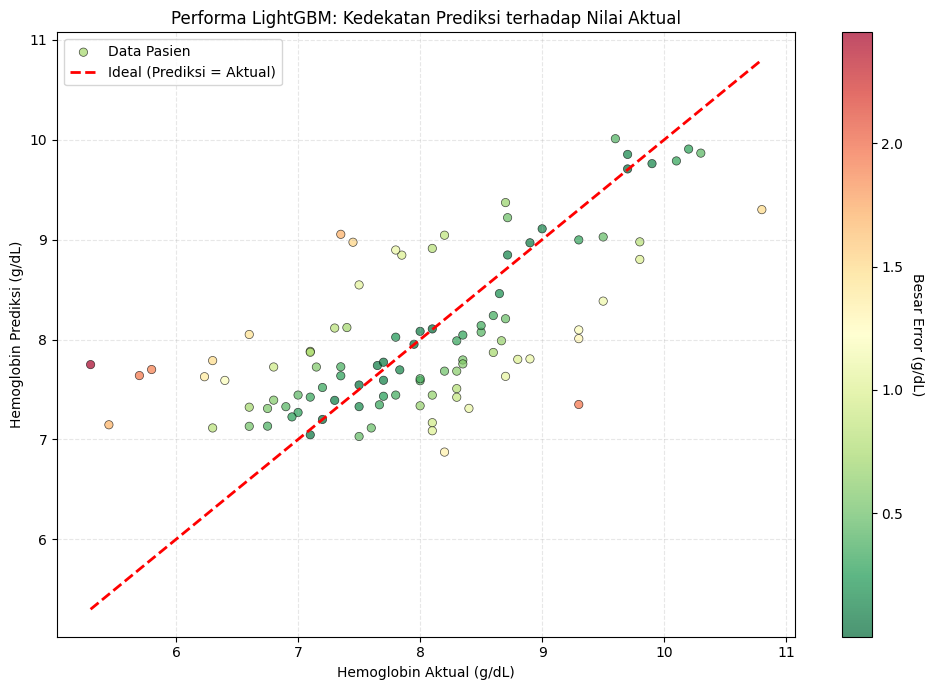

In [29]:
import numpy as np
import matplotlib.pyplot as plt

y_pred = models_final["LightGBM"].predict(X_test)
error_abs = np.abs(y_test - y_pred)

plt.figure(figsize=(10, 7))

# hijau untuk error kecil, merah untuk error besar)
scatter = plt.scatter(y_test, y_pred, 
                      c=error_abs, 
                      cmap='RdYlGn_r', 
                      alpha=0.7, 
                      edgecolors='k', 
                      linewidths=0.5,
                      label='Data Pasien')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Ideal (Prediksi = Aktual)')

cbar = plt.colorbar(scatter)
cbar.set_label('Besar Error (g/dL)', rotation=270, labelpad=15)

plt.xlabel("Hemoglobin Aktual (g/dL)")
plt.ylabel("Hemoglobin Prediksi (g/dL)")
plt.title("Performa LightGBM: Kedekatan Prediksi terhadap Nilai Aktual")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

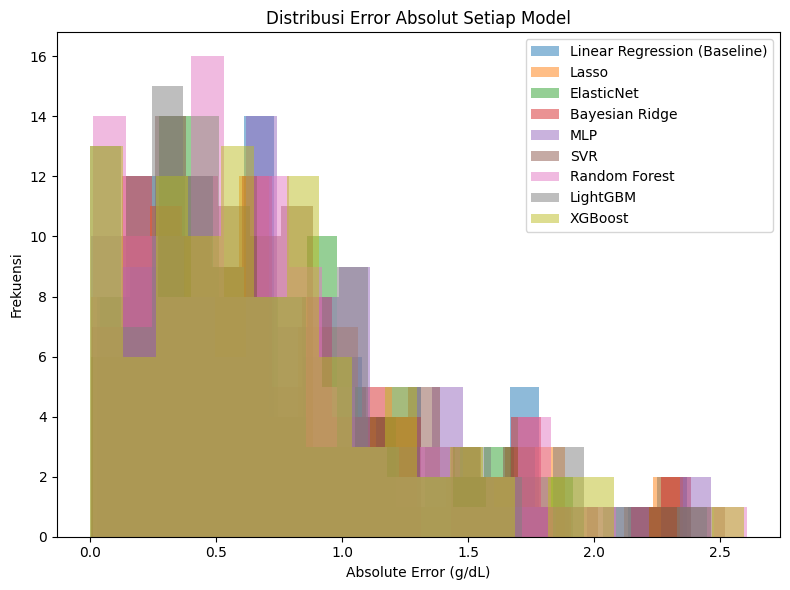

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for name, model in models_final.items():
    y_pred = model.predict(X_test)
    abs_error = np.abs(y_test - y_pred)
    
    plt.hist(abs_error, bins=20, alpha=0.5, label=name)

plt.xlabel("Absolute Error (g/dL)")
plt.ylabel("Frekuensi")
plt.title("Distribusi Error Absolut Setiap Model")
plt.legend()
plt.tight_layout()
plt.show()


C:\Users\Windows\AppData\Local\Temp\ipykernel_19932\3502629487.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(errors, labels=models_final.keys(), showfliers=False)


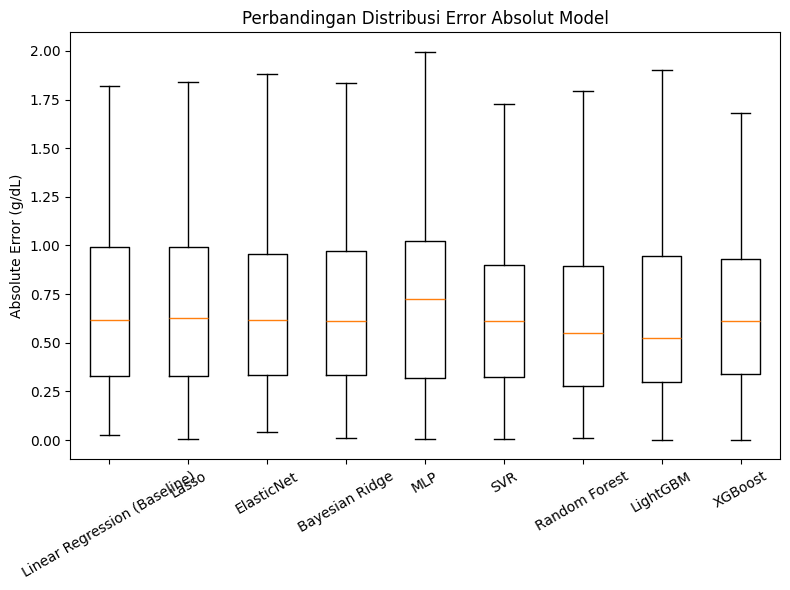

In [31]:
errors = []

for name, model in models_final.items():
    y_pred = model.predict(X_test)
    abs_error = np.abs(y_test - y_pred)
    errors.append(abs_error)

plt.figure(figsize=(8,6))
plt.boxplot(errors, labels=models_final.keys(), showfliers=False)
plt.ylabel("Absolute Error (g/dL)")
plt.title("Perbandingan Distribusi Error Absolut Model")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
